<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Longitudinal_CT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download and Extract Dataset

We will use the `requests` library to download the zip file and the `zipfile` module to extract its contents.

In [ ]:
import requests
import zipfile
import os

# URL of the dataset
dataset_url = "https://fdat.uni-tuebingen.de/records/75kj1-64747/files/Longitudinal_CT_v2.zip?download=1"
output_zip_filename = "Longitudinal_CT_v2.zip"
extraction_path = "./Longitudinal_CT_v2"

print(f"Downloading {output_zip_filename}...")
response = requests.get(dataset_url, stream=True)
response.raise_for_status() # Raise an exception for bad status codes

with open(output_zip_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print("Download complete.")

print(f"Extracting {output_zip_filename} to {extraction_path}...")
with zipfile.ZipFile(output_zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print("Extraction complete.")

# Optionally, remove the zip file after extraction
# os.remove(output_zip_filename)

print(f"Dataset downloaded and extracted to: {extraction_path}")

Download complete.
Extracting Longitudinal_CT_v2.zip to ./Longitudinal_CT_v2...
Extraction complete.
Dataset downloaded and extracted to: ./Longitudinal_CT_v2


### Upload Dataset to Google Cloud Storage

Since the dataset is large, we will stream it directly from the source URL to your GCS bucket `longitudinal-ct`.

In [1]:
from google.colab import auth
from google.cloud import storage
import requests

# Authenticate to Google Cloud
auth.authenticate_user()

def upload_to_bucket(url, bucket_name, destination_blob_name):
    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(destination_blob_name)

    print(f"Streaming {url} to gs://{bucket_name}/{destination_blob_name}...")

    # Stream the request
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        # Upload from file-like object
        blob.upload_from_file(r.raw, content_type='application/zip')

    print("Upload complete.")

bucket_name = 'longitudinal-ct'
dataset_url = "https://fdat.uni-tuebingen.de/records/75kj1-64747/files/Longitudinal_CT_v2.zip?download=1"
destination_zip = "Longitudinal_CT_v2.zip"

upload_to_bucket(dataset_url, bucket_name, destination_zip)

Streaming https://fdat.uni-tuebingen.de/records/75kj1-64747/files/Longitudinal_CT_v2.zip?download=1 to gs://longitudinal-ct/Longitudinal_CT_v2.zip...
Upload complete.


### Visualize Data Examples

Now that the dataset is downloaded and extracted, let's load a few examples using MONAI and visualize them with their labels.

In [ ]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 27.0 MB/s eta 0:00:00


Found 336 image-label pairs.
Visualizing sample 1:


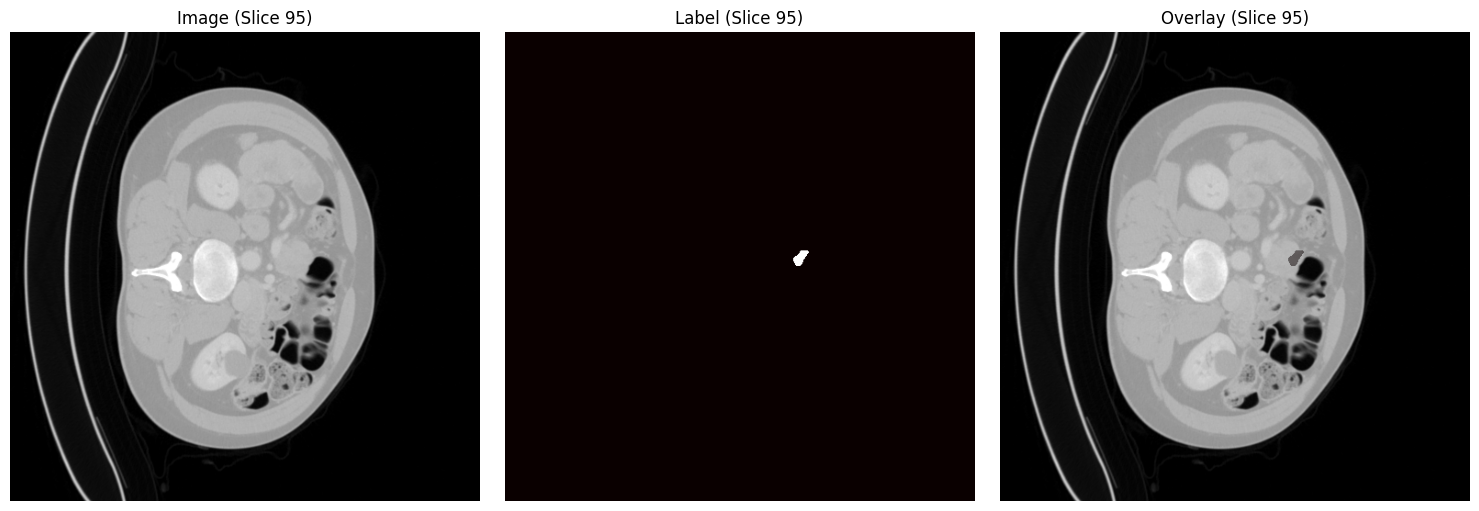

Visualizing sample 2:


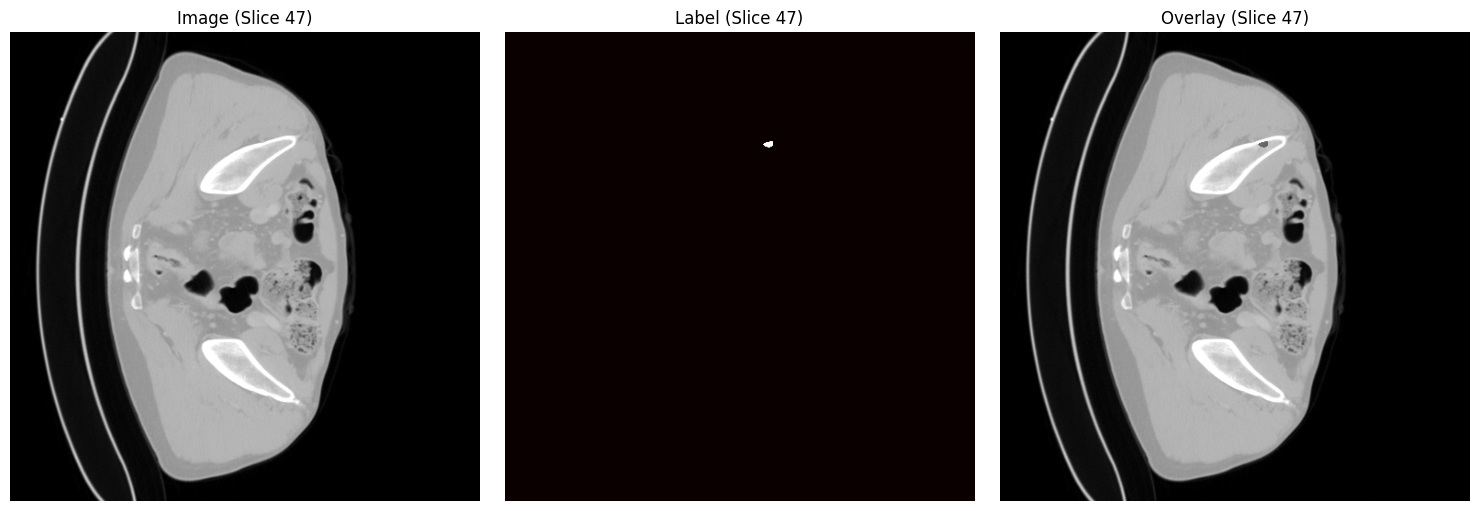

Visualizing sample 3:


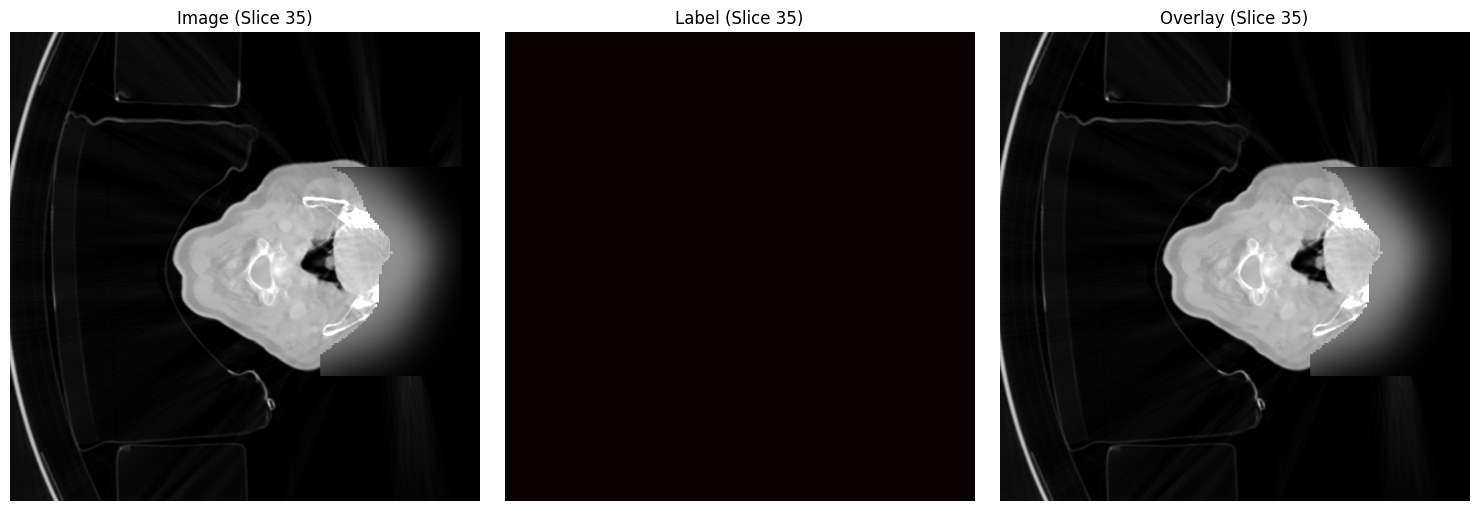

In [ ]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

from monai.transforms import (
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    Compose
)
from monai.data import Dataset, DataLoader

# Define data directories
data_dir = "./Longitudinal_CT_v2"
input_dir = os.path.join(data_dir, "inputsTr")
target_dir = os.path.join(data_dir, "targetsTr")

# Get lists of image and label paths
# Assuming a consistent naming convention where 'img' and 'mask' correspond
# We'll match them based on the base filename (e.g., 'patientID_visitID')

image_files = sorted(glob.glob(os.path.join(input_dir, "*_img_*.nii.gz")))
label_files = sorted(glob.glob(os.path.join(target_dir, "*_mask_*.nii.gz")))

# Create a dictionary list for MONAI Dataset
data_dicts = [
    {"image": img_name, "label": label_name}
    for img_name, label_name in zip(image_files, label_files)
]

print(f"Found {len(data_dicts)} image-label pairs.")

# Define transformations for loading and initial processing
# These are basic transformations, more complex ones would be needed for training
transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS"),
        # Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
        ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=500, b_min=0.0, b_max=1.0, clip=True),
    ]
)

# Create a dataset and dataloader
# Using a small batch size for visualization purposes
dataset = Dataset(data=data_dicts, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

# Visualize a few examples
def visualize_sample(sample_data):
    # Remove batch dimension -> (C, H, W, D)
    image = sample_data["image"][0]
    label = sample_data["label"][0]

    # Encontrar una rebanada (slice) que realmente contenga la máscara
    # Sumamos sobre las dimensiones espaciales Alto (0) y Ancho (1) del canal 0
    label_sum = label[0].sum(dim=(0, 1))

    if label_sum.max() > 0:
        # Seleccionar la rebanada con la mayor cantidad de pixeles en la máscara
        slice_idx = int(label_sum.argmax())
    else:
        # Si la máscara está completamente vacía, caemos en la rebanada del medio
        slice_idx = image.shape[-1] // 2

    img_slice = image[0, :, :, slice_idx].detach().cpu().numpy()
    lbl_slice = label[0, :, :, slice_idx].detach().cpu().numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_slice, cmap="gray")
    plt.title(f"Image (Slice {slice_idx})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(lbl_slice, cmap="hot") # Using 'hot' colormap for labels
    plt.title(f"Label (Slice {slice_idx})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_slice, cmap="gray")
    # Enmascarar los ceros en el label para hacerlos transparentes
    lbl_masked = np.ma.masked_where(lbl_slice == 0, lbl_slice)
    plt.imshow(lbl_masked, cmap="hot", alpha=0.5) # alpha controla la transparencia
    plt.title(f"Overlay (Slice {slice_idx})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Get and visualize the first 3 samples
for i, sample in enumerate(dataloader):
    if i >= 3:
        break
    print(f"Visualizing sample {i+1}:")
    visualize_sample(sample)
